## Линейный график со стилями (Line chart with styles)

In [9]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt 

## 1 Установливаем соединение с базой данных.

In [10]:
conn = sqlite3.connect('/Users/cleganeb/Desktop/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/data/checking-logs.sqlite')

## 2 Пронализируем пользователей из таблицы pageviews, переведем колонку datetime в формат дат и найдем уникальные даты.

In [11]:
query = """
SELECT datetime
FROM pageviews
WHERE uid LIKE 'user_%'
ORDER BY uid ASC
"""
pageviews = pd.io.sql.read_sql(query, conn)
pageviews['date'] = pd.to_datetime(pageviews['datetime']).dt.date
pageviews = pageviews.groupby('date').size().reset_index(name='views')

display(pageviews.head())

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1


## Сделаем тоже самое для таблицы checker.

In [12]:
query = """
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%'
ORDER BY uid ASC
"""
checker = pd.io.sql.read_sql(query, conn)
checker['date'] = pd.to_datetime(checker['timestamp']).dt.date
checker = checker.groupby('date').size().reset_index(name='commits')

display(checker.head())

,date,commits
0,2020-04-17,23
1,2020-04-18,69
2,2020-04-19,33
3,2020-04-20,25
4,2020-04-21,25


## 3 Проанализируем полученые данные и найдем только те даты, когда были одновременно и просмотры, и коммиты проверки. Выведем общую таблицу.

In [13]:
merge_df = pd.merge(pageviews, checker, on='date', how='inner')

display(merge_df.head())
print(len(merge_df))

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28


32


## 4 Построим график: размер шрифта должен быть 8, размер фигуры должен быть (15, 8).

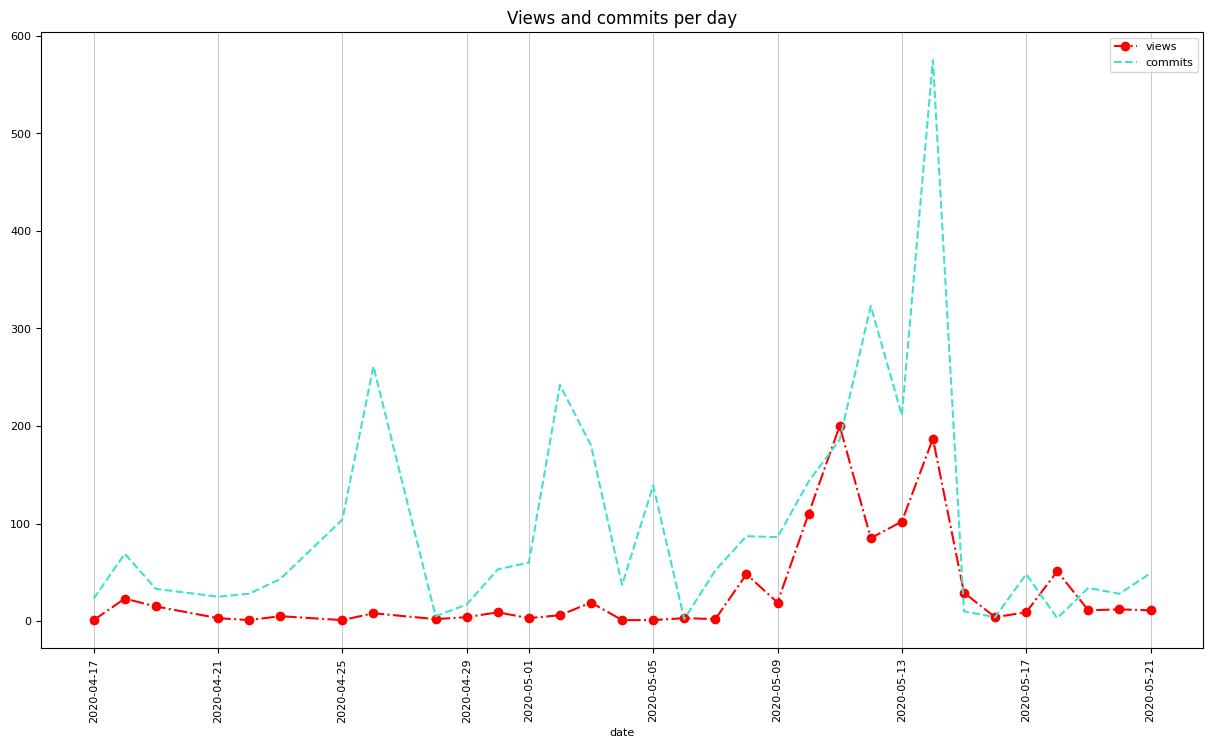

In [14]:
fig, ax = plt.subplots(figsize=(15, 8))

merge_df.set_index('date').plot(
    kind='line', 
    y='views', 
    style='-.', 
    marker='o', 
    color='red', 
    fontsize=8, 
    title='Views and commits per day', 
    ax=ax)

merge_df.set_index('date').plot(
    y='commits', 
    color='turquoise', 
    style='--', 
    ax=ax, 
    fontsize=8, 
    rot=90, 
    legend=True)

ax.set_xlabel('date', fontsize=8)
ax.set_ylabel('', fontsize=8)
ax.legend(fontsize=8)

for label in ax.get_xticklabels():
    label.set_rotation(90)

ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.5)
plt.show()

## 5 Сколько раз количество просмотров превышало 150?

In [15]:
view_value = (merge_df['views'].astype(float) > 150).sum()
print('Ответ:', view_value)

Ответ: 2


## 6 Закроем соединение с базой данных.

In [16]:
conn.close()